# Minneapolis Police Stop Analysis
#### Stat 319
#### Penn State University
#### Conrad Cliff, Felipe Rapacci

### **First Import The Data**

In [3]:
import pandas as pd
df = pd.read_csv("MplsStops.csv")
df.head()

,Unnamed: 0,idNum,date,problem,MDC,citationIssued,personSearch,vehicleSearch,preRace,race,gender,lat,long,policePrecinct,neighborhood
0,6823,17-000003,2017-01-01 00:00:42,suspicious,MDC,NaN,NO,NO,Unknown,Unknown,Unknown,44.966617,-93.246458,1,Cedar Riverside
1,6824,17-000007,2017-01-01 00:03:07,suspicious,MDC,NaN,NO,NO,Unknown,Unknown,Male,44.980450,-93.271340,1,Downtown West
2,6825,17-000073,2017-01-01 00:23:15,traffic,MDC,NaN,NO,NO,Unknown,White,Female,44.948350,-93.275380,5,Whittier
3,6826,17-000092,2017-01-01 00:33:48,suspicious,MDC,NaN,NO,NO,Unknown,East African,Male,44.948360,-93.281350,5,Whittier
4,6827,17-000098,2017-01-01 00:37:58,traffic,MDC,NaN,NO,NO,Unknown,White,Female,44.979078,-93.262076,1,Downtown West


### **Now, try to look through data to check what needs cleaning** 

#### Categorical:

In [4]:
columns = ["idNum","date", "problem", "MDC", 
           "citationIssued", "personSearch", 
           "vehicleSearch", "preRace", "race",
           "gender", "lat", "long", 
           "policePrecinct", "neighborhood"]
quantitative = ["idNum", "date", "lat", "long"]
categorical = [c for c in columns if c not in quantitative]
for column in categorical:
    print(f"___ {column} ___")
    print(df[column].value_counts(dropna=False), "\n")

___ problem ___
problem
traffic       26098
suspicious    25822
Name: count, dtype: int64 

___ MDC ___
MDC
MDC      43699
other     8221
Name: count, dtype: int64 

___ citationIssued ___
citationIssued
NaN    32810
NO     15899
YES     3211
Name: count, dtype: int64 

___ personSearch ___
personSearch
NO     38462
NaN     8221
YES     5237
Name: count, dtype: int64 

___ vehicleSearch ___
vehicleSearch
NO     40579
NaN     8221
YES     3120
Name: count, dtype: int64 

___ preRace ___
preRace
Unknown            28337
NaN                 8221
Black               6805
White               6004
Native American      908
Latino               528
Other                484
East African         481
Asian                152
Name: count, dtype: int64 

___ race ___
race
Black              15220
White              11703
Unknown             9219
NaN                 8221
East African        2188
Latino              1858
Native American     1516
Other               1348
Asian                647
Name:

#### Quantitative:

In [5]:
for column in quantitative:
    print(f"___ {column} ___")
    print(f"Percent null: {df[column].isnull().sum()/len(df) * 100}%", "\n")

___ idNum ___
Percent null: 0.0% 

___ date ___
Percent null: 0.0% 

___ lat ___
Percent null: 0.0% 

___ long ___
Percent null: 0.0% 



Overall, we can see that none of the quantitative data seems to need any cleaning. Some quantitative columns need cleaning due to NaN/"Unknown" values, namely: 
* citationIssued
* personSearch
* vehicleSearch
* preRace
* race
* gender

We will clean the data frame according to what variables will be used in our analyses.

### **Objectives and Analyses**

#### Main Question: How did police stop outcomes differ by stop type, race, and location in 2017 Minneapolis stops?
##### DEPENDENT VARIABLES:
The following variables, together, help describe the nature of the stop, we will be using them to represent the stop outcomes.
* person search - A physical and intrusive action, represent escalation beyond a routine stop;
* vehicle search - A disruption on privacy, represents suspicion and seriousness attributed to the stop;
* citation issued - The real legal outcome of the stop;

#### Single Variable Analyses
* Analysis 1 - Person Search Proportion
* Analysis 2 - Vehicle Search Proportion
* Analysis 3 - Citation Issued Proportion

#### Two Variable Analyses
* Analysis 4 - ...

#### Advance Method Analyses
* Analyses X - ...

### **Analysis 1, 2, 3 - Person Search, Vehicle Search, and Citation Issued Proportions**

In [15]:
dependentVar = ["personSearch", "vehicleSearch", "citationIssued"]

# Clean data by dropping rows with NaN in either of the variables 
df1 = df.dropna(subset=dependentVar)

# Get total number of cleaned stops
stopCount = len(df1.value_counts(dropna=False))

# Get number of stops that led to person searches, vehicle searches, and citations:
personSearchCount = (df1["personSearch"] == "YES").sum()
vehicleSearchCount = (df1["vehicleSearch"] == "YES").sum()
citationIssuedCount = (df1["citationIssued"] == "YES").sum()

# Get proportion for each
pSearchProportion = personSearchCount / stopCount
vSearchProportion = vehicleSearchCount / stopCount
citationProportion = citationIssuedCount / stopCount

# Percentages
psPerc = pSearchProportion * 100
vsPerc = vSearchProportion * 100
ciPerc = citationProportion * 100

print(f"Person Search: {psPerc:.2f}%\n"
      f"Vehicle Search: {vsPerc:.2f}%\n"
      f"Citation Issued: {ciPerc:.2f}%")



Person Search: 12.37%
Vehicle Search: 7.11%
Citation Issued: 16.80%


#### **Plotting the results:**

<function matplotlib.pyplot.show(close=None, block=None)>

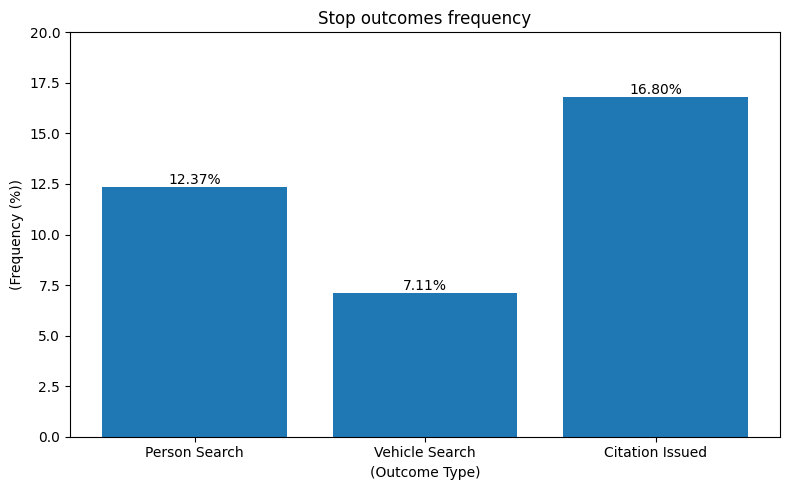

In [20]:
import matplotlib.pyplot as plt


labels = ['Person Search', 'Vehicle Search', 'Citation Issued']
values = [psPerc, vsPerc, ciPerc]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values)

ax.set_title("Stop outcomes frequency")
ax.set_xlabel("(Outcome Type)")
ax.set_ylabel("(Frequency (%))")
ax.set_ylim(0, 20)

ax.bar_label(bars, fmt='%.2f%%')

plt.tight_layout()
plt.show